In [1]:
import zarr
import matplotlib.pyplot as plt

In [2]:
spec = zarr.open_group('/home/100/mj8805/scr_mk27/Turbospectrum_NLTE/runs/ca_regular-grid/outputs/zarr/regular_ca_intensity.zarr')

In [3]:
spec.tree()

/
├── flux (8151, 40001) float32
├── model_id (8151,) uint64
├── mu_selected (8151,) float32
├── mu_selected_index (8151,) int16
├── param_names (10,) <U32
├── params (8151, 10) float32
├── physics_hash () <U64
├── provenance
│   ├── atmosphere_manifest.json () StringDType()
│   ├── canonical_config.yaml () StringDType()
│   ├── environment.txt () StringDType()
│   ├── linelist_manifest.json () StringDType()
│   ├── software_manifest.json () StringDType()
│   └── synthesis_config.yaml () StringDType()
├── schema_version () <U16
└── wavelength (40001,) float32

In [6]:
spec['flux'][0]

array([nan, nan, nan, ..., nan, nan, nan], shape=(40001,), dtype=float32)

In [4]:
import json

provenance = spec['provenance']
provenance_dict = {}

for key in provenance.array_keys():
    if key.endswith('.json'):
        data = provenance[key][()]
        # Decode to string if needed (zarr stores as bytes sometimes)
        if hasattr(data, 'decode'):
            data = data.decode('utf-8')
        provenance_dict[key] = json.loads(data)

# Now provenance_dict contains dicts for each json provenance file
for fname, jdata in provenance_dict.items():
    print(f"\n---- {fname} ----")
    print(json.dumps(jdata, indent=2))


---- atmosphere_manifest.json ----
{
  "geometry": "plane_parallel",
  "model_file_count": 15691,
  "path": "/scratch/mk27/mj8805/Turbospectrum_NLTE/input_files/model_atmospheres/1D/marcs_standard_comp",
  "sha256": "c82109845f2018d59916d6f500099458edd17a363fc6588298ae99586e9ef3a6",
  "version": "sha256:c82109845f2018d5"
}

---- linelist_manifest.json ----
{
  "files": [
    {
      "exists": true,
      "path": "/scratch/mk27/mj8805/Turbospectrum_NLTE/input_files/linelists/nlte_ges_linelist_jmg6may2025_I_II",
      "sha256": "7ea3064efcc94cbde9544e10e80252f374206028c2d19fdadf981b0cb4a4291b",
      "size_bytes": 15353679
    }
  ],
  "preprocessing": "",
  "sha256": "734c61bd40a83f582a4e656375b2f8bb67263e96164144ebb2fc2c2a7be4c85b",
  "source": "input_files/linelists",
  "version": "sha256:734c61bd40a83f58"
}

---- software_manifest.json ----
{
  "binaries_hash": "84d8d8ec0be97c7b945f14e99367d83067a891bbd8a3d99b2d4e4e5c37117e96",
  "compiler": "gf",
  "generator": "turbospectrum_nlte.

/jobfs/161395643.gadi-pbs/ipykernel_852516/3358486451.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


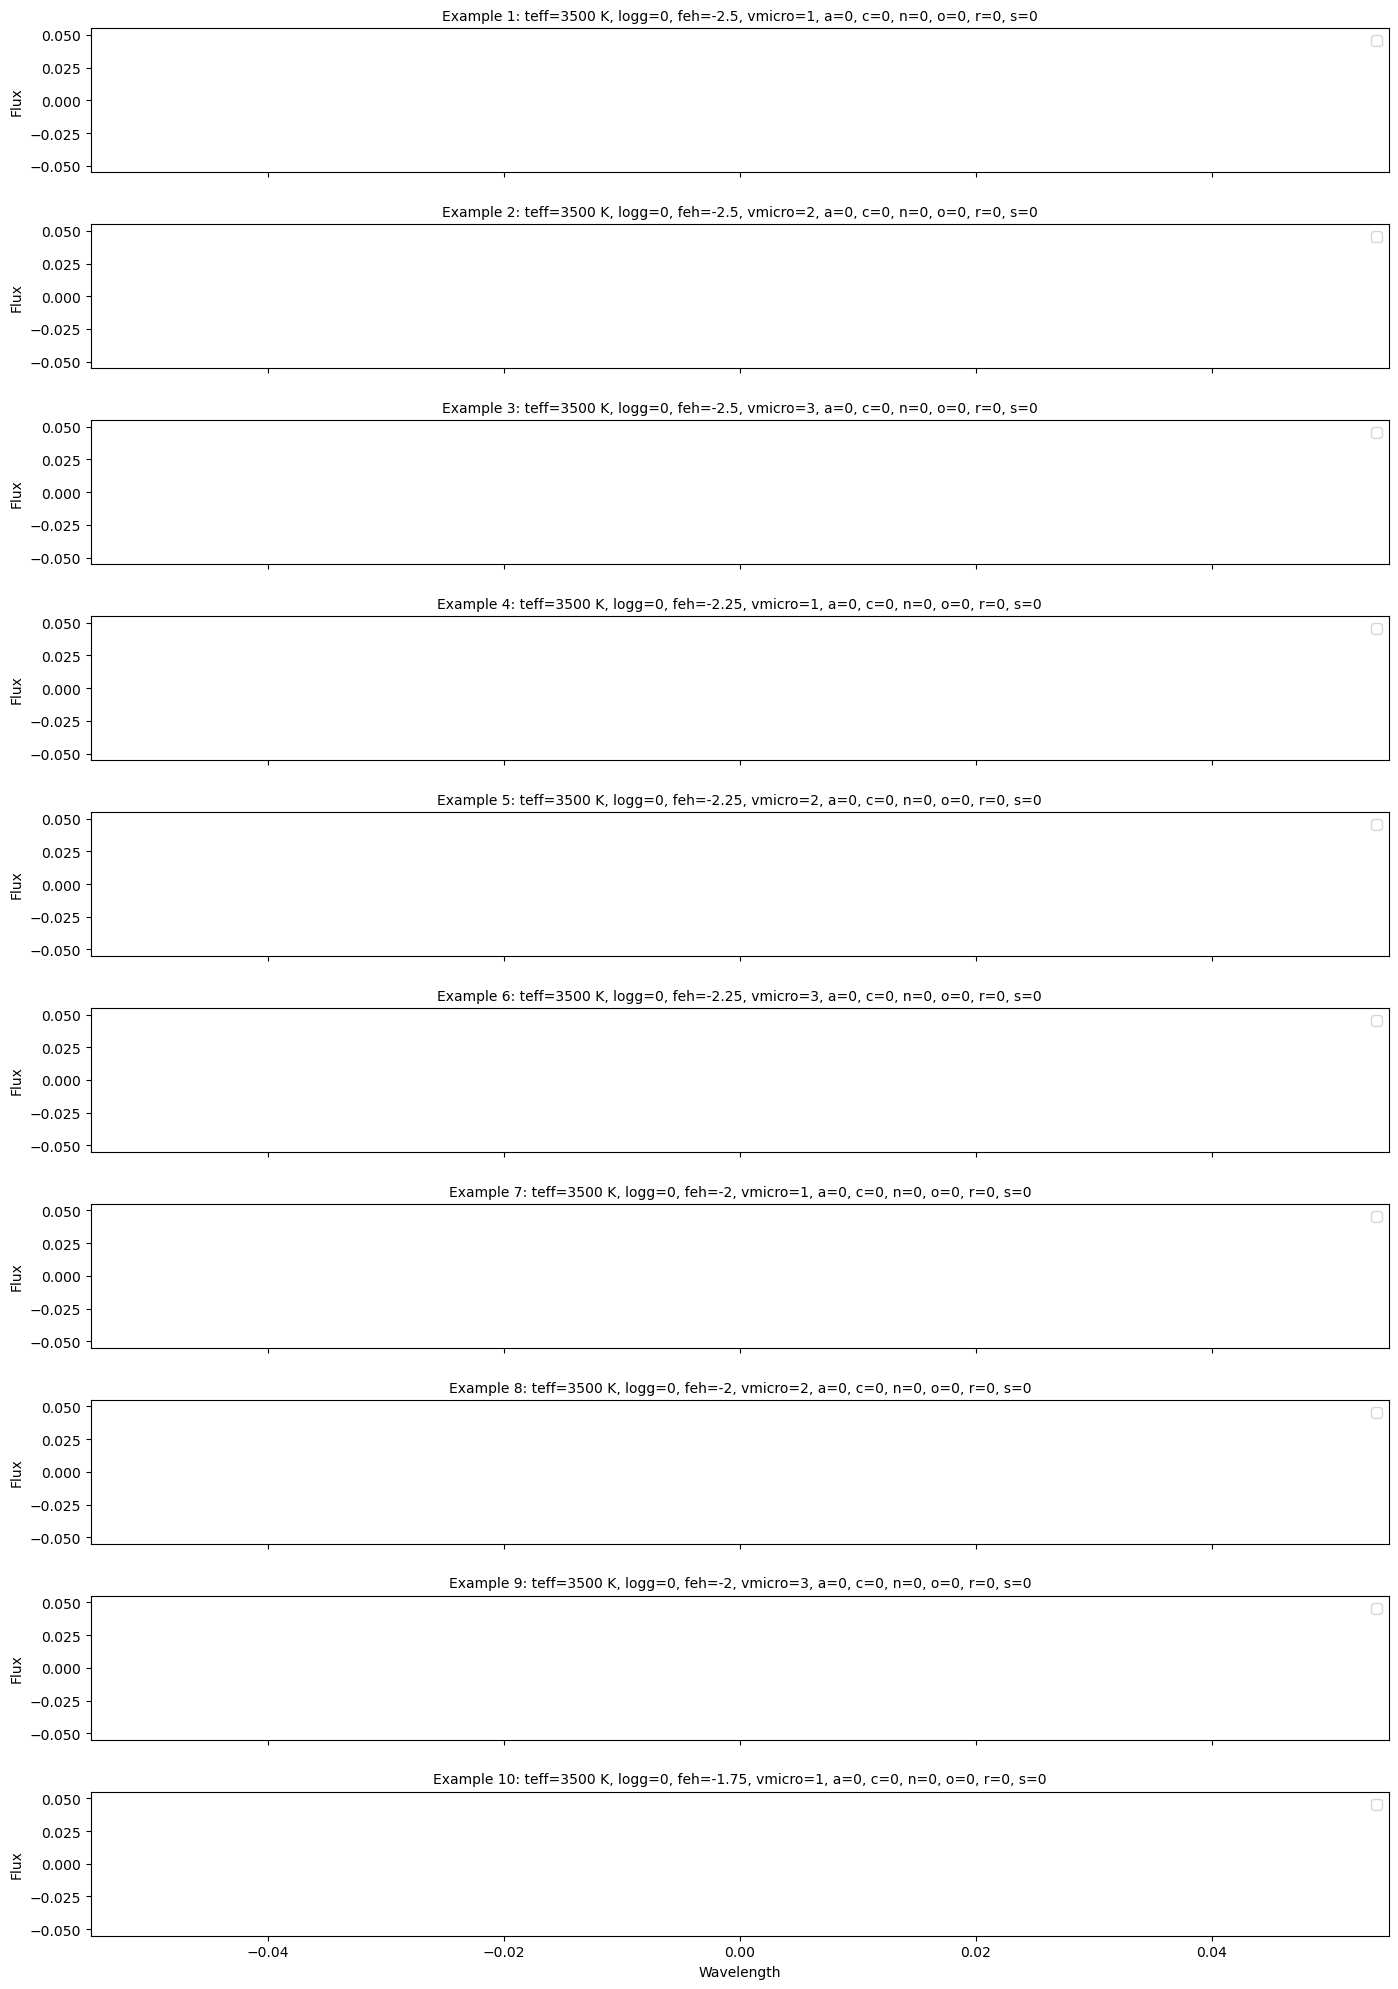

In [5]:
fig, axes = plt.subplots(10, 1, figsize=(14, 20), sharex=True)
wavelengths = spec['wavelength'][()]
params = spec['params'][:10]  # Shape (10, n_params)
param_names = spec['param_names'][()]   # Shape (n_params,); np.str_ type

for i in range(10):
    ax = axes[i]
    ax.plot(wavelengths, spec['flux'][i], color='black')
    param_strs = []
    for name, val in zip(param_names, params[i]):
        if name.lower() == "teff":
            param_strs.append(f"{name}={int(round(val))} K")
        else:
            param_strs.append(f"{name}={val:.3g}")
    ax.set_ylabel('Flux')
    ax.set_title(f'Example {i+1}: ' + ', '.join(param_strs), fontsize=10)
    ax.legend()

axes[-1].set_xlabel('Wavelength')

plt.tight_layout(h_pad=2)
plt.show()